# 문제 6 — 좌표 변환 체인과 회전축 복원

로봇 팔이 카메라가 본 물체를 집으려면 **camera → link → base** 로 이어지는
변환을 타고 내려와야 합니다. TF2 가 현장에서 해 주는 일을 직접 구현합니다.

$$T^{base}_{cam} = T^{base}_{link}\,T^{link}_{cam},\qquad
\mathbf{p}_{base}=T^{base}_{cam}\begin{bmatrix}\mathbf{p}_{cam}\\1\end{bmatrix}$$

윗첨자/아랫첨자가 **이웃끼리 상쇄**되도록 곱하면 순서를 틀리지 않습니다.

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 6-1 | base→link, link→camera 두 변환을 정의하고 카메라 좌표를 base 로 바꾸기 | `CoordinateChain`, `default_chain`, `camera_point_to_base` |
| 6-2 | **왕복 검증** + 점군을 **반복문 없이** 한 번에 변환, 점 개수별 왕복 오차 그래프 | `transform`, `base_point_to_camera` |
| 6-3 | base·camera 좌표계와 변환된 점군을 **3D 로 함께 시각화** | — |
| 6-4 | **고유값 분해로 회전축 복원**, 대각합으로 회전각, 축 불변 확인 | `axis_angle_from_matrix` |
| 6-5 | 단위 쿼터니언을 만들어 SciPy 와 비교하고 **부호가 반대로 나올 수 있는 이유** 설명 | `quaternion_from_axis_angle` |

> 완성한 체인은 `src/coordinate_chain.py` 로 내보냅니다.
> 모듈 ④ 미니 프로젝트에서 그대로 import 해 쓰므로 함수 이름을 바꾸지 마세요.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.coordinate_chain import (CoordinateChain, base_point_to_camera,
                                  camera_point_to_base, default_chain)
from src.rotation import (axis_angle_from_matrix, quaternion_from_axis_angle, rodrigues,
                          rot_x, rot_y, rot_z)
from src.transform import inv_T, make_T, transform_points
from src.vectors import det, normalize

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


def draw_frame(ax, T, scale=0.15, name="", alpha=1.0):
    """동차변환 T 가 나타내는 좌표계를 그린다. (그대로 쓰면 됩니다)"""
    o = T[:3, 3]
    for i, c in enumerate(["r", "g", "b"]):
        ax.quiver(*o, *(T[:3, i] * scale), color=c, alpha=alpha, arrow_length_ratio=0.2)
    if name:
        ax.text(*(o + 0.03), name, fontsize=10, weight="bold")


print("SciPy Rotation 사용 가능")

SciPy Rotation 사용 가능


## 6-1. 체인 구성과 카메라 → base 변환

`src/coordinate_chain.py` 의 `CoordinateChain` 은 부모-자식 관계를 등록해 두면
임의의 두 프레임 사이 변환을 알아서 조립합니다 (TF2 의 축소판).

지시문은 '임의의 회전·병진'을 쓰라고 하지만, 채점 수치를 맞추기 위해
아래 값을 권장합니다 (`default_chain` 의 docstring 과 같은 값).

- `base → link` : z축 30도 회전 후 (0.30, 0.00, 0.40) m 이동
- `link → camera` : y축 -20도, x축 90도 회전 후 (0.10, 0.05, 0.15) m 이동

문제 2 의 `rot_*` 와 문제 5 의 `make_T`/`inv_T` 를 그대로 재사용합니다.

**할 일** — `CoordinateChain` 의 `_path_to_root`, `T_from_root`, `T`, `transform` 과
`default_chain`, `camera_point_to_base` 를 구현하고 아래를 확인하세요.

In [2]:
chain = default_chain()

# TODO: T(base<-link), T(link<-camera), T(base<-camera) 를 출력하고
#       체인이 조립한 결과가 두 행렬의 곱과 같은지 확인하세요.

T_base_link = chain.get("base", "link")
T_link_cam = chain.get("link", "camera")
T_base_cam = chain.T("base", "camera")

print("T_base_link =\n", T_base_link)
print("\nT_link_camera =\n", T_link_cam)
print("\nT_base_camera = T_base_link @ T_link_camera =\n", T_base_cam)
print("\n곱셈으로 직접 조립한 것과 같은가 :", np.allclose(T_base_cam, T_base_link @ T_link_cam))

T_base_link =
 [[ 0.866025 -0.5       0.        0.3     ]
 [ 0.5       0.866025  0.        0.      ]
 [ 0.        0.        1.        0.4     ]
 [ 0.        0.        0.        1.      ]]

T_link_camera =
 [[ 0.939693 -0.34202  -0.        0.1     ]
 [ 0.        0.       -1.        0.05    ]
 [ 0.34202   0.939693  0.        0.15    ]
 [ 0.        0.        0.        1.      ]]

T_base_camera = T_base_link @ T_link_camera =
 [[ 0.813798 -0.296198  0.5       0.361603]
 [ 0.469846 -0.17101  -0.866025  0.093301]
 [ 0.34202   0.939693  0.        0.55    ]
 [ 0.        0.        0.        1.      ]]

곱셈으로 직접 조립한 것과 같은가 : True


In [3]:
p_cam = np.array([0.20, -0.05, 0.60])       # 카메라가 본 물체 (60 cm 앞)
p_base = camera_point_to_base(p_cam, chain)

# TODO: camera_point_to_base 로 base 기준 좌표를 구해 출력하세요.
# TODO: base 원점에서의 거리, 카메라 원점의 base 기준 위치도 출력하세요.
print("\n카메라 기준 물체 좌표 :", p_cam)
print("base  기준 물체 좌표 :", p_base)
print("base 원점에서의 거리  : {:.4f} m".format(np.linalg.norm(p_base)))
print("카메라 원점 위치      :", T_base_cam[:3, 3])


카메라 기준 물체 좌표 : [ 0.2  -0.05  0.6 ]
base  기준 물체 좌표 : [ 0.839172 -0.323794  0.571419]
base 원점에서의 거리  : 1.0656 m
카메라 원점 위치      : [0.361603 0.093301 0.55    ]


In [4]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 체인 조립 결과가 행렬 곱과 일치하는가
#   - 합성 변환이 유효한 동차변환인가 (회전부 det = 1, 직교)
#   - 카메라 원점 (0,0,0) 이 base 에서 T 의 병진 성분으로 가는가
#   - 역방향 체인 T(camera<-base) == inv_T(T(base<-camera)) 인가
#   - 변환이 두 점 사이 거리를 보존하는가
ok = check("체인 조립이 행렬 곱과 일치", np.allclose(T_base_cam, T_base_link @ T_link_cam))
ok &= check("합성 변환이 유효한 동차변환 (회전부 det = 1)", np.isclose(det(T_base_cam[:3, :3]), 1.0))
ok &= check("회전부가 직교", np.allclose(T_base_cam[:3, :3].T @ T_base_cam[:3, :3], np.eye(3)))
ok &= check("카메라 원점(0,0,0)은 base 에서 T 의 병진 성분",
            np.allclose(camera_point_to_base([0, 0, 0], chain), T_base_cam[:3, 3]))
ok &= check("역방향 체인 T(camera<-base) == inv(T(base<-camera))",
            np.allclose(chain.T("camera", "base"), inv_T(T_base_cam)))
ok &= check("거리는 변환에 대해 불변 (두 점 사이 거리)",
            np.isclose(np.linalg.norm(camera_point_to_base([1., 0., 0.], chain)
                                      - camera_point_to_base([0., 0., 0.], chain)), 1.0))
print("\n6-1 전체 통과:", ok)

[PASS] 체인 조립이 행렬 곱과 일치
[PASS] 합성 변환이 유효한 동차변환 (회전부 det = 1)
[PASS] 회전부가 직교
[PASS] 카메라 원점(0,0,0)은 base 에서 T 의 병진 성분
[PASS] 역방향 체인 T(camera<-base) == inv(T(base<-camera))
[PASS] 거리는 변환에 대해 불변 (두 점 사이 거리)

6-1 전체 통과: True


## 6-2. 왕복 검증과 점군 벡터화

base 로 바꾼 좌표를 다시 카메라 기준으로 되돌리면 원래 값이 나와야 합니다.
수학적으로는 $T^{-1}T=I$ 라 당연하지만, 부동소수점에서는 아주 작은 오차가 남습니다.

점이 여러 개일 때는 반복문 대신 **한 번의 행렬 곱**으로 처리합니다.

$$P_{base}=P_{cam,h}\,T^{\mathsf{T}}\qquad (N\times 4)\cdot(4\times 4)$$

$(T P^{\mathsf{T}})^{\mathsf{T}}$ 대신 $P T^{\mathsf{T}}$ 를 쓰는 편이 유리한 이유도 생각해 보세요.

**할 일**

- 단일 점의 왕복 오차를 출력하세요.
- (N,3) 점군을 한 번에 변환하고, 반복문 결과와 일치하는지 확인하세요.
- 점 개수를 1 → 100만 까지 늘려 가며 **왕복 오차(최대·RMS)와 소요 시간**을 표로 출력하고,
  로그-로그 그래프 2개(오차 / 시간)로 그리세요.
- 점 개수가 늘어도 오차가 **누적되지 않는 이유**를 적으세요.

### 관찰과 해석

- 왕복 오차가 점 개수에 따라 어떻게 변하는가: `_오차가 점 개수에 따라 누적되지 않는다_`
- 그 이유: `_벡터화 결과 == 반복문 결과_`
- 벡터화가 반복문보다 빠른 이유: `_변환이 점 사이 거릴르 본존하기 때문에_`

In [5]:
# TODO: 단일 점 왕복 검증 (p_cam -> base -> camera) 오차를 출력하세요.
p_back = base_point_to_camera(p_base, chain)
print("원래 카메라 좌표 :", p_cam)
print("왕복 후          :", p_back)
print("왕복 오차        : {:.3e}".format(np.linalg.norm(p_back - p_cam)))

원래 카메라 좌표 : [ 0.2  -0.05  0.6 ]
왕복 후          : [ 0.2  -0.05  0.6 ]
왕복 오차        : 2.517e-16


In [6]:
# TODO: (1000, 3) 점군을 만들어 한 번에 변환하고,
P_cam = rng.uniform(-0.5, 0.5, size=(1000, 3)) + np.array([0.0, 0.0, 0.8])
P_base = chain.transform("base", "camera", P_cam)      # 내부적으로 P_h @ T.T
P_back = chain.transform("camera", "base", P_base)

#       반복문 결과와 일치하는지 / 왕복 최대 오차를 출력하세요.
print("\n점군 shape :", P_cam.shape, "->", P_base.shape)
print("반복문 결과와 일치 :",
      np.allclose(P_base, np.array([camera_point_to_base(p, chain) for p in P_cam])))
print("왕복 최대 오차 : {:.3e}".format(np.max(np.linalg.norm(P_back - P_cam, axis=1))))


점군 shape : (1000, 3) -> (1000, 3)
반복문 결과와 일치 : True
왕복 최대 오차 : 4.743e-16


In [7]:
counts = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]
max_errs, rms_errs, times_vec, times_loop = [], [], [], []

# TODO: 점 개수별로 왕복 오차(최대/RMS)와 벡터화·반복문 소요 시간을 재서 표로 출력하세요.
#       (반복문은 느리므로 1만 개까지만 재고 나머지는 np.nan 으로 두면 됩니다)

for n in counts:
    P = rng.uniform(-0.5, 0.5, size=(n, 3)) + np.array([0.0, 0.0, 0.8])

    t0 = time.perf_counter()
    Pb = chain.transform("base", "camera", P)
    Pk = chain.transform("camera", "base", Pb)
    times_vec.append(time.perf_counter() - t0)

    e = np.linalg.norm(Pk - P, axis=1)
    max_errs.append(float(np.max(e)))
    rms_errs.append(float(np.sqrt(np.mean(e ** 2))))

    if n <= 10_000:                       # 반복문은 느려서 1만 개까지만
        t0 = time.perf_counter()
        _ = np.array([camera_point_to_base(p, chain) for p in P])
        times_loop.append(time.perf_counter() - t0)
    else:
        times_loop.append(np.nan)

print("{:>10}{:>16}{:>16}{:>14}{:>14}".format("점 개수", "최대 왕복오차", "RMS 왕복오차", "벡터화 [ms]", "반복문 [ms]"))
print("-" * 72)
for n, me, re_, tv, tl in zip(counts, max_errs, rms_errs, times_vec, times_loop):
    tl_s = "-" if np.isnan(tl) else "{:.2f}".format(tl * 1e3)
    print("{:>10,}{:>16.3e}{:>16.3e}{:>14.2f}{:>14}".format(n, me, re_, tv * 1e3, tl_s))

      점 개수         최대 왕복오차        RMS 왕복오차      벡터화 [ms]      반복문 [ms]
------------------------------------------------------------------------
         1       5.551e-17       5.551e-17          0.22          0.09
        10       2.618e-16       1.740e-16          0.11          0.65
       100       3.331e-16       1.584e-16          0.12          4.53
     1,000       4.743e-16       1.654e-16          3.64         40.14
    10,000       4.871e-16       1.700e-16          0.43        388.62
   100,000       6.081e-16       1.697e-16          4.74             -
 1,000,000       6.081e-16       1.695e-16         71.15             -


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

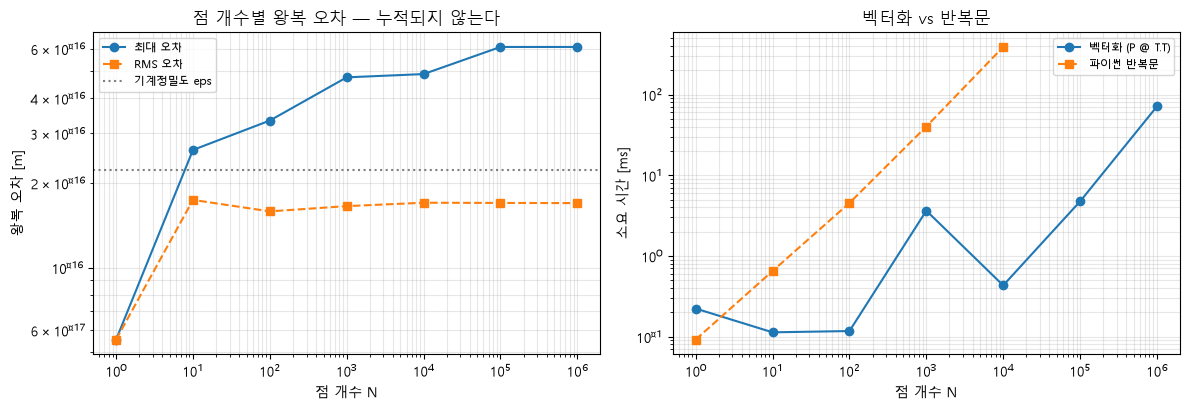

In [8]:
# TODO: 그래프 2개를 그리세요.
#   왼쪽  : 점 개수별 왕복 오차 (loglog, 기계정밀도 eps 기준선 추가)
#   오른쪽: 벡터화 vs 반복문 소요 시간 (loglog)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].loglog(counts, max_errs, "o-", label="최대 오차")
axes[0].loglog(counts, rms_errs, "s--", label="RMS 오차")
axes[0].axhline(np.finfo(float).eps, color="gray", ls=":", label="기계정밀도 eps")
axes[0].set_xlabel("점 개수 N")
axes[0].set_ylabel("왕복 오차 [m]")
axes[0].set_title("점 개수별 왕복 오차 — 누적되지 않는다")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend(fontsize=8)

valid = ~np.isnan(times_loop)
axes[1].loglog(counts, np.array(times_vec) * 1e3, "o-", label="벡터화 (P @ T.T)")
axes[1].loglog(np.array(counts)[valid], np.array(times_loop)[valid] * 1e3, "s--",
               label="파이썬 반복문")
axes[1].set_xlabel("점 개수 N")
axes[1].set_ylabel("소요 시간 [ms]")
axes[1].set_title("벡터화 vs 반복문")
axes[1].grid(alpha=0.3, which="both")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

In [9]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 단일 점 왕복 오차가 기계정밀도 수준인가
#   - 점군 왕복 오차도 기계정밀도 수준인가
#   - 오차가 점 개수에 따라 누적되지 않는가
#   - 벡터화 결과 == 반복문 결과
#   - 1만 개에서 벡터화가 반복문보다 빠른가
#   - 변환이 점 사이 거리를 보존하는가
ok = check("단일 점 왕복 오차가 기계정밀도 수준", np.linalg.norm(p_back - p_cam) < 1e-15)
ok &= check("점군 왕복 오차도 기계정밀도 수준", max(max_errs) < 1e-14)
ok &= check("오차가 점 개수에 따라 누적되지 않는다 (100만 개도 1e-14 미만)", max_errs[-1] < 1e-14)
ok &= check("벡터화 결과 == 반복문 결과",
            np.allclose(P_base, np.array([camera_point_to_base(p, chain) for p in P_cam])))
ok &= check("1만 개에서 벡터화가 반복문보다 빠르다",
            times_vec[counts.index(10_000)] < times_loop[counts.index(10_000)])
ok &= check("변환이 점 사이 거리를 보존",
            np.allclose(np.linalg.norm(P_base[1:] - P_base[:-1], axis=1),
                        np.linalg.norm(P_cam[1:] - P_cam[:-1], axis=1)))
print("\n6-2 전체 통과:", ok)

[PASS] 단일 점 왕복 오차가 기계정밀도 수준
[PASS] 점군 왕복 오차도 기계정밀도 수준
[PASS] 오차가 점 개수에 따라 누적되지 않는다 (100만 개도 1e-14 미만)
[PASS] 벡터화 결과 == 반복문 결과
[PASS] 1만 개에서 벡터화가 반복문보다 빠르다
[PASS] 변환이 점 사이 거리를 보존

6-2 전체 통과: True


## 6-3. 좌표계와 점군 3D 시각화

base·link·camera 세 좌표계와, 카메라가 본 점군을 base 기준으로 옮긴 결과를 함께 그립니다.
점군이 **카메라 앞쪽(카메라 z축 방향)** 에 놓여야 기하적으로 타당합니다.

**할 일**

- 카메라 기준으로 z축 앞 0.7 m 근처에 점군 300개를 만드세요.
- 왼쪽: 카메라 기준 점군, 오른쪽: base 기준 점군 + 세 좌표계 를 2분할로 그리세요.
- 체인 연결선(base → link → camera)과 카메라 시선(z축)을 함께 그리면 판단하기 쉽습니다.

In [10]:
# TODO: 점군을 만들고 base 기준으로 변환하세요.
P_show_cam = rng.uniform(-0.15, 0.15, size=(300, 3)) + np.array([0.0, 0.0, 0.7])
P_show_base = chain.transform("base", "camera", P_show_cam)

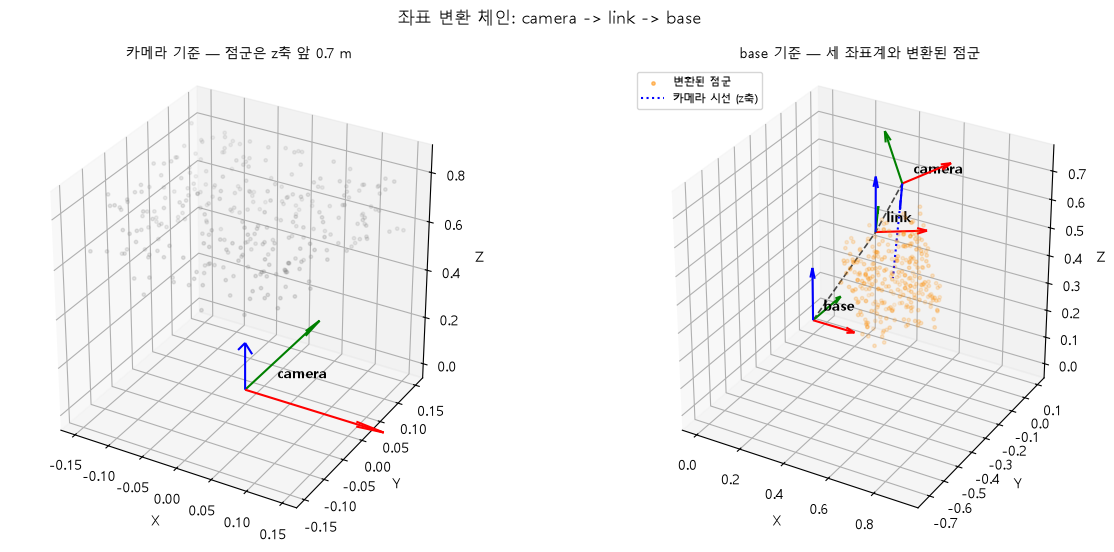

In [11]:
# TODO: 2분할 3D 그림을 그리세요.
fig = plt.figure(figsize=(13, 5.4))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(*P_show_cam.T, s=6, alpha=0.5, color="gray")
draw_frame(ax, np.eye(4), scale=0.2, name="camera")
ax.set_title("카메라 기준 — 점군은 z축 앞 0.7 m", fontsize=10)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.scatter(*P_show_base.T, s=6, alpha=0.5, color="darkorange", label="변환된 점군")
draw_frame(ax, np.eye(4), scale=0.2, name="base")
draw_frame(ax, chain.T_from_root("link"), scale=0.2, name="link")
draw_frame(ax, T_base_cam, scale=0.2, name="camera")

# 체인 연결선
pts = np.array([[0, 0, 0], chain.T_from_root("link")[:3, 3], T_base_cam[:3, 3]])
ax.plot(*pts.T, "k--", lw=1.2, alpha=0.7)
# 카메라 z축(시선) 을 점군 중심까지 연장
cam_o = T_base_cam[:3, 3]
ax.plot(*np.array([cam_o, P_show_base.mean(axis=0)]).T, color="b", ls=":", lw=1.5,
        label="카메라 시선 (z축)")

ax.set_title("base 기준 — 세 좌표계와 변환된 점군", fontsize=10)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_box_aspect([1, 1, 1])
ax.legend(fontsize=8, loc="upper left")

fig.suptitle("좌표 변환 체인: camera -> link -> base", fontsize=12)
fig.tight_layout()
plt.show()

In [12]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 점군 중심이 카메라 z축(시선) 방향에 있는가 (내적으로 확인)
#   - 점군 중심까지 거리가 약 0.7 m 인가
#   - 점군의 퍼짐(분산)이 변환 후에도 보존되는가
#   - link 원점이 base 에서 기대한 위치에 있는가
centroid_base = P_show_base.mean(axis=0)
cam_axis_z = T_base_cam[:3, 2]
to_centroid = normalize(centroid_base - cam_o)

ok = check("점군 중심이 카메라 z축(시선) 방향에 있다",
           np.dot(to_centroid, cam_axis_z) > 0.99)
ok &= check("점군 중심까지 거리가 약 0.7 m",
            np.isclose(np.linalg.norm(centroid_base - cam_o), 0.7, atol=0.02))
ok &= check("점군의 퍼짐(분산)이 변환 후에도 보존",
            np.isclose(np.trace(np.cov(P_show_cam.T)), np.trace(np.cov(P_show_base.T))))
ok &= check("link 원점이 base 에서 (0.30, 0, 0.40)",
            np.allclose(chain.T_from_root("link")[:3, 3], [0.30, 0.0, 0.40]))
print("\n6-3 전체 통과:", ok)

[PASS] 점군 중심이 카메라 z축(시선) 방향에 있다
[PASS] 점군 중심까지 거리가 약 0.7 m
[PASS] 점군의 퍼짐(분산)이 변환 후에도 보존
[PASS] link 원점이 base 에서 (0.30, 0, 0.40)

6-3 전체 통과: True


## 6-4. 고유값 분해로 회전축 복원

**오일러 회전 정리**: 3차원의 모든 회전은 어떤 축 하나를 중심으로 한 회전이다.

회전축 $\mathbf{k}$ 는 회전에 의해 변하지 않는 방향이므로

$$R\mathbf{k}=\mathbf{k}=1\cdot\mathbf{k}$$

즉 **고유값 1 에 대응하는 고유벡터**입니다.
회전행렬의 고유값 세 개가 각각 어떤 값인지 직접 출력해 확인해 보세요.

회전각은 대각합에서 나옵니다. 고유값의 합 = 대각합이라는 사실에서
$\mathrm{tr}(R)$ 와 $\theta$ 의 관계를 직접 유도하세요.

**주의할 점 두 가지**

- `arccos` 의 치역이 $[0,\pi]$ 라 **어느 쪽으로 도는지**는 알 수 없습니다.
- 고유벡터는 **부호가 정해지지 않습니다**.

이 둘을 어떻게 해결할지 정하고(힌트: $R-R^{\mathsf{T}}$ 를 전개해 보세요) 구현하세요.
$\theta=0$ 과 $\theta=\pi$ 는 따로 처리해야 합니다 — 각각 왜 그런지도 적으세요.

### 유도와 규약

- trace 와 회전각의 관계: `_대각합, 고유값의 합_`
- 축의 부호를 정하는 방법: `_반대칭 성분으로 축의 부호를 맞춘다. R - R^T = 2sinθ[k]_x_`
- theta = 0 / theta = pi 처리: _$\theta = 0$일 때는 회전이 없어 축이 무의미하므로 임의의 축(예: $[1, 0, 0]$)을 반환하고, $\theta = \pi$일 때는 $\text{tr}(R) = -1$이 되어 $\arccos$ 계산이 불가능하므로 $R + I$의 대각 성분 중 가장 큰 값을 이용해 축을 구해야 합니다.__

In [13]:
# TODO: R_chain = T(base<-camera) 의 회전 부분을 꺼내
#       np.linalg.eig 로 고유값 세 개를 출력하고, 고유값 1 의 고유벡터를 확인하세요.
R_chain = T_base_cam[:3, :3]

eigvals, eigvecs = np.linalg.eig(R_chain)
print("고유값 :")
for lam in eigvals:
    print("   {:+.6f} {:+.6f}i   |lambda| = {:.6f}".format(lam.real, lam.imag, abs(lam)))

idx = int(np.argmin(np.abs(eigvals - 1.0)))
print("\n고유값 1 의 인덱스 :", idx, " -> 고유벡터(실수부) :", np.real(eigvecs[:, idx]))

고유값 :
   +1.000000 +0.000000i   |lambda| = 1.000000
   -0.178606 +0.983921i   |lambda| = 1.000000
   -0.178606 -0.983921i   |lambda| = 1.000000

고유값 1 의 인덱스 : 0  -> 고유벡터(실수부) : [0.917614 0.080281 0.389282]


In [14]:
# TODO: axis_angle_from_matrix 로 축과 각을 복원해 출력하세요 (도 단위도 함께).
# TODO: trace(R) 로 구한 cos(theta) 도 출력해 비교하세요.
# TODO: 축 불변 검증 — R @ axis 와 axis 를 비교하세요.
axis, angle = axis_angle_from_matrix(R_chain)
angle_deg = np.degrees(angle)

print("\n복원한 회전축 :", axis, "  (길이 {:.6f})".format(np.linalg.norm(axis)))
print("복원한 회전각 : {:.6f} rad = {:.6f} 도".format(angle, angle_deg))
print("\ntrace(R) = {:.6f}  ->  cos(theta) = (tr - 1)/2 = {:.6f}".format(
    np.trace(R_chain), (np.trace(R_chain) - 1) / 2))

print("\n[축 불변 검증]")
print("  R @ axis =", R_chain @ axis)
print("  axis     =", axis)
print("  차이     : {:.3e}".format(np.linalg.norm(R_chain @ axis - axis)))

# TODO: 복원한 축/각으로 rodrigues 를 돌려 원래 R 이 나오는지 확인하세요.
from src.rotation import rodrigues
R_rebuilt = rodrigues(axis, angle)
print("\n복원한 축/각으로 재구성한 R 과 원본의 최대 차이 : {:.3e}".format(
    np.max(np.abs(R_rebuilt - R_chain))))


복원한 회전축 : [0.917614 0.080281 0.389282]   (길이 1.000000)
복원한 회전각 : 1.750366 rad = 100.288585 도

trace(R) = 0.642788  ->  cos(theta) = (tr - 1)/2 = -0.178606

[축 불변 검증]
  R @ axis = [0.917614 0.080281 0.389282]
  axis     = [0.917614 0.080281 0.389282]
  차이     : 1.144e-16

복원한 축/각으로 재구성한 R 과 원본의 최대 차이 : 2.796e-16


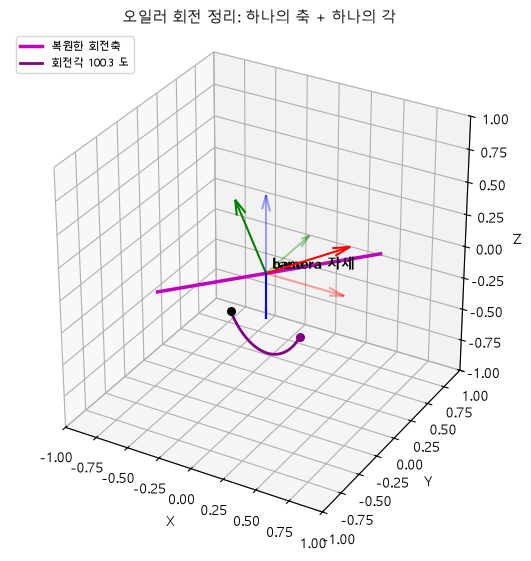

In [15]:
# TODO: (권장) 3D 그림 하나 — base 좌표계, 복원한 회전축(직선),
#       축 둘레를 theta 만큼 도는 호(arc)를 그려 '축 + 각' 을 시각화하세요.
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(111, projection="3d")

draw_frame(ax, np.eye(4), scale=0.6, name="base", alpha=0.35)
draw_frame(ax, make_T(R_chain, [0, 0, 0]), scale=0.6, name="camera 자세")

k = axis * 0.9
ax.plot([-k[0], k[0]], [-k[1], k[1]], [-k[2], k[2]], "m-", lw=2.5, label="복원한 회전축")

# 축 주위를 도는 궤적으로 회전각 표시
perp = normalize(np.cross(axis, [0, 0, 1] if abs(axis[2]) < 0.9 else [1, 0, 0])) * 0.55
arc = np.array([rodrigues(axis, a) @ perp for a in np.linspace(0, angle, 60)])
ax.plot(*arc.T, color="purple", lw=2, label="회전각 {:.1f} 도".format(angle_deg))
ax.scatter(*perp, color="k", s=30)
ax.scatter(*arc[-1], color="purple", s=30)

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
ax.set_box_aspect([1, 1, 1])
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("오일러 회전 정리: 하나의 축 + 하나의 각", fontsize=11)
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

In [16]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 고유값 중 하나가 1 인가 / 세 고유값의 절댓값이 모두 1 인가
#   - 복원한 축이 단위벡터인가
#   - R @ axis == axis (축 불변), R.T @ axis == axis 인가
#   - trace 로 구한 각이 고유값의 위상과 일치하는가
#   - 복원한 축/각으로 R 을 재구성할 수 있는가
#   - SciPy 의 회전벡터 크기와 각이 일치하는가 (# 비교 대상)
ok = check("고유값 중 하나가 1", np.isclose(np.min(np.abs(eigvals - 1.0)), 0.0))
ok &= check("고유값의 절댓값이 모두 1", np.allclose(np.abs(eigvals), 1.0))
ok &= check("복원한 축이 단위벡터", np.isclose(np.linalg.norm(axis), 1.0))
ok &= check("R @ axis == axis (축 불변)", np.allclose(R_chain @ axis, axis))
ok &= check("R^T @ axis == axis (역회전에도 불변)", np.allclose(R_chain.T @ axis, axis))
ok &= check("trace 로 구한 각이 고유값 위상과 일치",
            np.isclose(angle, np.abs(np.angle(eigvals[np.argmax(np.abs(eigvals.imag))]))))
ok &= check("복원한 축/각으로 R 을 재구성할 수 있다", np.allclose(R_rebuilt, R_chain))
ok &= check("SciPy 의 회전벡터 크기와 일치",
            np.isclose(angle, np.linalg.norm(Rotation.from_matrix(R_chain).as_rotvec())))
print("\n6-4 전체 통과:", ok)

[PASS] 고유값 중 하나가 1
[PASS] 고유값의 절댓값이 모두 1
[PASS] 복원한 축이 단위벡터
[PASS] R @ axis == axis (축 불변)
[PASS] R^T @ axis == axis (역회전에도 불변)
[PASS] trace 로 구한 각이 고유값 위상과 일치
[PASS] 복원한 축/각으로 R 을 재구성할 수 있다
[PASS] SciPy 의 회전벡터 크기와 일치

6-4 전체 통과: True


## 6-5. 단위 쿼터니언과 SciPy 비교 — 부호는 왜 반대로 나올 수 있나

축 $\mathbf{k}$, 각 $\theta$ 에서 단위 쿼터니언은

$$q=\left(\mathbf{k}\sin\tfrac{\theta}{2},\;\cos\tfrac{\theta}{2}\right)\quad (x,y,z,w)$$

**할 일**

- 복원한 축·각으로 쿼터니언을 만들고 `Rotation.from_matrix(R).as_quat()` 와 비교하세요.
- 부호까지 같은지 / 부호를 무시하면 같은지 각각 확인하고, $|q \cdot q_{ref}|$ 도 보세요.
- $q$ 와 $-q$ 를 각각 회전행렬로 되돌려 보고, 무엇을 알 수 있는지 적으세요.
- **축을 뒤집고 각을 $2\pi-\theta$ 로 바꾸면** 어떤 쿼터니언이 나오는지 확인하세요.
- 위 관찰을 모아 **부호가 반대로 나올 수 있는 이유**를 설명하고,
  실무에서 비교·보간할 때 어떻게 다뤄야 하는지 적으세요.

### 부호 차이의 이유와 실무 대처

- 관찰: `___`
- 이유: `___`
- 비교할 때: `___`
- 보간(SLERP)·필터에 쓸 때: `___`

In [17]:
# TODO: q_mine = quaternion_from_axis_angle(axis, angle) 와
#       q_scipy = Rotation.from_matrix(R_chain).as_quat() 를 비교 출력하세요.
q_mine = quaternion_from_axis_angle(axis, angle)          # (x, y, z, w)
q_scipy = Rotation.from_matrix(R_chain).as_quat()         # SciPy 도 (x, y, z, w)
print("직접 계산 q :", q_mine)
print("SciPy    q :", q_scipy)
print("\n부호까지 같은가        :", np.allclose(q_mine, q_scipy))
print("부호를 무시하면 같은가 :", np.allclose(q_mine, q_scipy) or np.allclose(q_mine, -q_scipy))
print("내적 |q · q_scipy|     : {:.12f}  (1 이면 같은 회전)".format(abs(q_mine @ q_scipy)))
print("\n노름 : {:.12f} / {:.12f}".format(np.linalg.norm(q_mine), np.linalg.norm(q_scipy)))

# TODO: q 와 -q 를 각각 회전행렬로 되돌려 원본과의 오차를 출력하세요.
print("\nq  -> R 최대 오차 : {:.3e}".format(
    np.max(np.abs(Rotation.from_quat(q_mine).as_matrix() - R_chain))))
print("-q -> R 최대 오차 : {:.3e}".format(
    np.max(np.abs(Rotation.from_quat(-q_mine).as_matrix() - R_chain))))

# TODO: 축을 뒤집고 각을 2pi - theta 로 바꾼 쿼터니언도 만들어 비교하세요.
q_flip = quaternion_from_axis_angle(-axis, 2 * np.pi - angle)
print("\n축을 뒤집고 각을 2pi-theta 로 :", q_flip)
print("원래 q 의 부호 반전과 일치     :", np.allclose(q_flip, -q_mine))

직접 계산 q : [0.704416 0.061628 0.298836 0.640856]
SciPy    q : [0.704416 0.061628 0.298836 0.640856]

부호까지 같은가        : True
부호를 무시하면 같은가 : True
내적 |q · q_scipy|     : 1.000000000000  (1 이면 같은 회전)

노름 : 1.000000000000 / 1.000000000000

q  -> R 최대 오차 : 1.665e-16
-q -> R 최대 오차 : 1.665e-16

축을 뒤집고 각을 2pi-theta 로 : [-0.704416 -0.061628 -0.298836 -0.640856]
원래 q 의 부호 반전과 일치     : True


In [18]:
# --- 검증 ---
# TODO: 아래 항목을 check(...) 로 검증하세요.
#   - 직접 계산한 쿼터니언이 단위 노름인가
#   - SciPy 결과와 부호를 무시하면 일치하는가
#   - |q · q_scipy| == 1 인가
#   - q 와 -q 로 복원한 R 이 모두 원본과 일치하는가
#   - 축 반전 + (2pi - theta) 가 -q 를 주는가
#   - 무작위 회전 100개에서 부호를 무시하면 항상 일치하는가
ok = check("직접 계산한 쿼터니언이 단위 노름", np.isclose(np.linalg.norm(q_mine), 1.0))
ok &= check("SciPy 결과와 부호 무시하고 일치",
            np.allclose(q_mine, q_scipy) or np.allclose(q_mine, -q_scipy))
ok &= check("|q · q_scipy| == 1 (같은 회전)", np.isclose(abs(q_mine @ q_scipy), 1.0))
ok &= check("q 로 복원한 R 이 원본과 일치",
            np.allclose(Rotation.from_quat(q_mine).as_matrix(), R_chain))
ok &= check("-q 로 복원한 R 도 원본과 일치 (이중 덮개)",
            np.allclose(Rotation.from_quat(-q_mine).as_matrix(), R_chain))
ok &= check("축 반전 + (2pi - theta) 가 -q 를 준다", np.allclose(q_flip, -q_mine))
ok &= check("무작위 회전 100개에서 부호 무시 시 항상 일치", all(
    (lambda A, B: np.allclose(A, B) or np.allclose(A, -B))(
        quaternion_from_axis_angle(*axis_angle_from_matrix(Rr)),
        Rotation.from_matrix(Rr).as_quat())
    for Rr in [rot_z(a) @ rot_y(b_) @ rot_x(c)
               for a, b_, c in rng.uniform(-np.pi, np.pi, (100, 3))]))
print("\n6-5 전체 통과:", ok)

[PASS] 직접 계산한 쿼터니언이 단위 노름
[PASS] SciPy 결과와 부호 무시하고 일치
[PASS] |q · q_scipy| == 1 (같은 회전)
[PASS] q 로 복원한 R 이 원본과 일치
[PASS] -q 로 복원한 R 도 원본과 일치 (이중 덮개)
[PASS] 축 반전 + (2pi - theta) 가 -q 를 준다
[PASS] 무작위 회전 100개에서 부호 무시 시 항상 일치

6-5 전체 통과: True


## 답안 템플릿 정리

In [19]:
summary = """
1. 카메라 좌표에서 base 좌표로의 변환 결과
   p_cam  = {pc} ->  p_base = {pb}
   사용한 체인: T(base<-camera) = T_base_link @ T_link_camera

2. 왕복 검증: 단일 점 오차 {e1:.3e}, 점군 100만 개에서 최대 {e2:.3e}
   - 점 개수별 오차 그래프: 위 왼쪽 그림
   - 오차가 누적되지 않는 이유: _각 점이 독립적으로 T^-1 T 를 한 번 통과할 뿐이라 오차는 기계정밀도에 머문다._
   - 벡터화 vs 반복문 속도 (1만 개):  {speed:.0f}배

3. 좌표계와 점군 3D 시각화: 위 2분할 그림 참조
   - 기하적으로 타당하다고 판단한 근거: 점군 중심이 카메라 z축 방향, 거리 0.7 m, base-link-camera 연결 확인

4. 복원한 회전축: {ax} / 회전각: {ang:.6f} 도
   - 축 불변 검증: {inv} (|R k - k| = {axerr:.3e})
   - 축과 각을 구한 방법: 고유값 1 의 고유벡터, 각은 tr(R) = 1 + 2 cos(theta) 에서 구했다.
     arccos 치역이 [0, pi] 라 부호는 R - R^T = 2 sin(theta) [k]x 로 결정했다.

5. 쿼터니언 비교 (x, y, z, w)
   - 직접 계산: {qm}
   - SciPy    : {qs}
   - 부호 무시하고 일치: {qeq},  |q · q_scipy| = {qdot:.12f}
   - 부호 차이의 이유: q 와 -q 는 같은 회전이다(이중 덮개). 회전행렬 복원식이 q 에 대해
     2차식이라 부호가 상쇄되고, 기하적으로도 '축 k 로 +theta' 와 '축 -k 로 2pi-theta' 가
     같은 자세를 준다. 비교할 때는 q == +-q_ref 로 확인하고,
     보간/필터에 쓸 때는 w >= 0 으로 부호를 정렬해 둔다.
""".format(
    pc=p_cam, pb=np.round(p_base, 6),
    e1=float(np.linalg.norm(p_back - p_cam)), e2=max_errs[-1],
    speed=times_loop[counts.index(10_000)] / times_vec[counts.index(10_000)],
    ax=np.round(axis, 6), ang=angle_deg,
    inv=bool(np.allclose(R_chain @ axis, axis)),
    axerr=float(np.linalg.norm(R_chain @ axis - axis)),
    qm=np.round(q_mine, 6), qs=np.round(q_scipy, 6),
    qeq=bool(np.allclose(q_mine, q_scipy) or np.allclose(q_mine, -q_scipy)),
    qdot=abs(q_mine @ q_scipy)
)
print(summary)


1. 카메라 좌표에서 base 좌표로의 변환 결과
   p_cam  = [ 0.2  -0.05  0.6 ] ->  p_base = [ 0.839172 -0.323794  0.571419]
   사용한 체인: T(base<-camera) = T_base_link @ T_link_camera

2. 왕복 검증: 단일 점 오차 2.517e-16, 점군 100만 개에서 최대 6.081e-16
   - 점 개수별 오차 그래프: 위 왼쪽 그림
   - 오차가 누적되지 않는 이유: _각 점이 독립적으로 T^-1 T 를 한 번 통과할 뿐이라 오차는 기계정밀도에 머문다._
   - 벡터화 vs 반복문 속도 (1만 개):  901배

3. 좌표계와 점군 3D 시각화: 위 2분할 그림 참조
   - 기하적으로 타당하다고 판단한 근거: 점군 중심이 카메라 z축 방향, 거리 0.7 m, base-link-camera 연결 확인

4. 복원한 회전축: [0.917614 0.080281 0.389282] / 회전각: 100.288585 도
   - 축 불변 검증: True (|R k - k| = 1.144e-16)
   - 축과 각을 구한 방법: 고유값 1 의 고유벡터, 각은 tr(R) = 1 + 2 cos(theta) 에서 구했다.
     arccos 치역이 [0, pi] 라 부호는 R - R^T = 2 sin(theta) [k]x 로 결정했다.

5. 쿼터니언 비교 (x, y, z, w)
   - 직접 계산: [0.704416 0.061628 0.298836 0.640856]
   - SciPy    : [0.704416 0.061628 0.298836 0.640856]
   - 부호 무시하고 일치: True,  |q · q_scipy| = 1.000000000000
   - 부호 차이의 이유: q 와 -q 는 같은 회전이다(이중 덮개). 회전행렬 복원식이 q 에 대해
     2차식이라 부호가 상쇄되고, 기하적으로도 '축 k 로 +theta' 와 '축 -k 로 2pi-theta